# Sentiment Analysis - Embedding text for FFNN

## Goals: 
- Learning Objectives
- Motivation
- Function
- Read Data
- Remove unwanted review characters and Wordcloud
- Data Preprocessing
    - Create binary sentiment columns
    - Create TensorFlow dataset and split into training, validation, test
    - Identify unique words (tokens) in the training dataset
    - Encoding: sequences of words into sequences of integers
    - Divide the dataset into mini-batches as input to the model
    - Create features (embeddings)
- Model 
    - Build model
    - Compile model
    - Fit model
    - Model Evaluation
- Inspecting Learned Embeddings
    - Apply PCA to reduce embeddings to 2D
    - Visualize PCA embeddings
- Evaluation

## Motivation

The IMDB dataset serves as a benchmark in Natural Language Processing (NLP) because it represents a real-world application of sentiment classification. In the modern digital economy, businesses rely on automated systems to parse millions of user-generated reviews to gauge brand reputation, product quality, and customer satisfaction. 

Manually auditing text is impossible at scale; therefore, developing models that can accurately distinguish between positive and negative is critical. This dataset provides a challenging environment for training models due to the presence of linguistic nuances such as sarcasm, negation (e.g., "not good"), and complex sentence structures. Mastering this task demonstrates proficiency in handling unstructured text data and implementing deep learning architectures capable of capturing long-range semantic dependencies.

## Learning Objectives

By completing a project using the IMDB dataset, we will achieve the following:

- **Text Preprocessing & Tokenization:** Learn to clean raw text by removing HTML tags, punctuation, and stopwords, and implement techniques such as word tokenization, padding, and truncation to prepare sequences for neural networks.
- **Feature Engineering (Word Embeddings):** Understand how to transform discrete text into dense vector representations using methods like Word2Vec, GloVe, or learnable embedding layers within a model.
- **Sequence Modeling:** Gain hands-on experience implementing various architectures for sequential data, we will focus on FFNN - Feedforward Neural Network.
- **Performance Evaluation:** Learn to evaluate classification models using metrics beyond simple accuracy, such as Precision, Recall, F1-Score, and Confusion Matrices, to account for potential class imbalances or error types.
- **Regularization & Optimization:** Apply techniques like Dropout, and gradient clipping to prevent overfitting and ensure the model generalizes well to unseen movie reviews.

## Import Packages

In [1]:
import numpy as np
import pandas as pd
import random
import re
from collections import Counter

# plot
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# tf
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.decomposition import PCA


## Functions

In [2]:
# clean up the review sentences
def preprocessor(text):
    text = re.sub('<[^<]*>', '', text) # replace anythin in <> to empty, *: means count as 'zero or more occurences'
    emoticons = re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)', text) # return all emoticons
    text = (re.sub('[\W]+', ' ', text.lower()) +  # matches all non-alphanumeric character (anything that is not letter, number, or underscore), this includes punctuation, symbols, and whitespace.
            ' '.join(emoticons).replace('-', ''))
    return text

In [3]:
# define function for token encoer
def encode(text_tensor, label):
    text = text_tensor.numpy()[0]
    encoded_text = encoder.encode(text)
    return encoded_text, label

# Wraps a python-based encoding function so it can be executed within a TensorFlow computational graph
def encode_map_fn(text, label): 
    return tf.py_function(encode, inp=[text, label], # funciton; input variables; output types
                          Tout=(tf.int64, tf.int64))

## Read data

In [4]:
df_init = pd.read_csv('IMDB Dataset.csv')
print(f'Shape of the data: ', df_init.shape)
print(f'Unique sentiment: ', df_init.sentiment.unique())
df_init.head()

Shape of the data:  (50000, 2)
Unique sentiment:  ['positive' 'negative']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


There are 50000 reviews, wht sentiment as positive or negative. 'review' column would be the feature, and 'sentiment' would be the target.

**`wordcloud: review the words`**
- A Word Cloud is a visual representation of text data where the size of each word indicates its frequency or importance within a given body of text.

    - A WordCloud object cannot read a list or a DataFrame column directly; **it requires one single, massive string containing all the text**.

    - **' '.join(...)**: This takes every single review in that column and glues them together into one giant string, placing a space ' ' between each review.

    - **.generate()**: This is the command that triggers the actual math. It takes the giant string you just created, performs the word frequency counting, applies the max_words limit, and calculates the layout of the words on the 800x400 canvas.


In [5]:
# apply cleanup function to 'review', remove unwanted review characters
df_init['review'] = df_init['review'].apply(preprocessor)

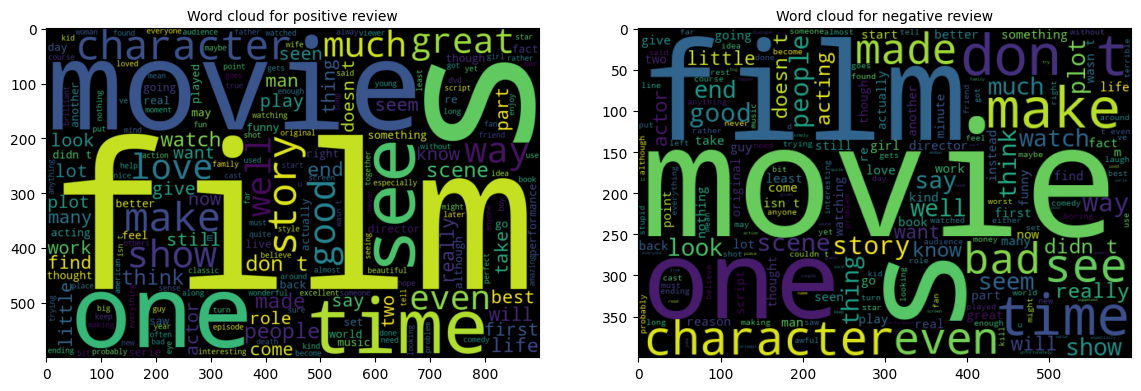

In [6]:
# apply wordcloud to review the top words - positive review
df_init_positive = df_init[df_init['sentiment'] == 'positive']
fig, axis = plt.subplots(1,2,figsize=(14,6))
wc = WordCloud(
    max_words=200,
    width=900,
    height=600).generate(' '.join(df_init_positive['review']))
axis[0].imshow(wc, interpolation='bilinear')
axis[0].set_title('Word cloud for positive review', fontsize=10)

# apply wordcloud to review the top words - negative review
df_init_negative = df_init[df_init['sentiment'] == 'negative']
wc = WordCloud(
    max_words=200,
    width=600,
    height=400).generate(' '.join(df_init_negative['review']))
axis[1].imshow(wc, interpolation='bilinear')
axis[1].set_title('Word cloud for negative review', fontsize=10);

## Data Preprocessing
1) Create binary sentiment columns
2) Create TensorFlow dataset and split into training, validation, test
3) Identify unique words (tokens) in the training dataset
4) Encoding: sequences of words into sequences of integers
5) Divide the dataset into mini-batches as input to the model
6) Create features (embeddings)

##### `1) Create binary sentiment columns`

- convert string to number: positive - 1; negative - 0

In [7]:
df_init['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [8]:
df_init['sentiment'] = np.where(df_init['sentiment'] == 'positive', 1, 0)

In [9]:
df_init['sentiment'].value_counts()

sentiment
1    25000
0    25000
Name: count, dtype: int64

In [10]:
df_init

,review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically there s a family where a little boy ...,0
4,petter mattei s love in the time of money is a...,1
...,...,...
49995,i thought this movie did a down right good job...,1
49996,bad plot bad dialogue bad acting idiotic direc...,0
49997,i am a catholic taught in parochial elementary...,0
49998,i m going to have to disagree with the previou...,0


##### `2) Create TensorFlow dataset and split trainig, validation, test`

In [11]:
target = df_init['sentiment']

In [12]:
# target and review combined tensors. create a TensorFlow Dataset object where each element is a tuple containing one slice from a and b, like zip(a,b) function
data_tf = tf.data.Dataset.from_tensor_slices(
    (df_init[['review']].values, target.values)
)

In [13]:
tf.random.set_seed(1)

# train, validation, test split
splits = [0.6, 0.2, 0.2]

# shuffle whole data; don't reshuffle every epoch
data_tf = data_tf.shuffle(buffer_size=df_init.shape[0], reshuffle_each_iteration=False)

# split
data_tf_test = data_tf.take(int(df_init.shape[0] * splits[2]))
data_tf_train_valid = data_tf.skip(int(df_init.shape[0] * splits[2]))

data_tf_train = data_tf.take(int(df_init.shape[0] * splits[0]))
data_tf_valid = data_tf.skip(int(df_init.shape[0] * splits[0]))

##### `3) Identify unique words (tokens) in the training dataset`

In [14]:
# initialize tokenizer, use to split test to word (tokens)
try:
    tokenizer = tfds.features.text.Tokenizer()
except:
    tokenizer = tfds.deprecated.text.Tokenizer()

token_counts = Counter()
for example in data_tf_train:
    tokens = tokenizer.tokenize(example[0].numpy()[0])
    token_counts.update(tokens) # update the counts of each word

print(f'Total training vocabulary: {len(token_counts)}')

Total training vocabulary: 83961


2026-06-29 16:30:24.400445: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


##### `4) Encoding: sequences of words into sequences of integers`

In [15]:
# initialize encoder
try: 
    encoder = tfds.features.text.TokenTextEncoder(token_counts)
except:
    encoder = tfds.deprecated.text.TokenTextEncoder(token_counts)

# apply encode function to each record
data_tf_train = data_tf_train.map(encode_map_fn)
data_tf_valid = data_tf_valid.map(encode_map_fn)
data_tf_test = data_tf_test.map(encode_map_fn)

In [16]:
# review the first 2 examples
for example in data_tf_train.take(2):
    print(example[0])

tf.Tensor(
[  1   2   3   4   5   6   7   8   9  10  11  12  13  11  14  12  15  16
   2  17  18  19  20  21  22   7  23  24  25  26  27  25  20  28  29   7
   8  30  18  31  32  33  34  35  36  37  25  38   7   2  39  40  41  42
  43   8  44  45  46  11  47  18  25  48  49  50  42  51  52  33  53  54
  29   7   8  55  42  12  56  57   2  58  11  12  52  59  60  61  62  63
  64  42  65  20  66  67  32  68  69  12  59  70  25  71  61  72  29  73
  74  42  43  75  25  76  77  78  53  79  80  81  60  34  82   8  83  60
  84  85  86  42  65  20  10  87  60  88  89  90  91  92  67  93   2  94
  18  95  96  41  25  97  98  99 100 101 102 103  68   4 104 105  42 106
 107   2 108  18  12 109   7   8 110 111 112 113 114  18 115  62 116  18
  79 117  12 118  42 119  38   7 120 121  12 122], shape=(192,), dtype=int64)
tf.Tensor(
[ 12 123  11  20 124   7 125 126  42 105   2 127 128 129 130 131  69 132
 133 134 124 114 129 125  62  18 135 136 100 137 138 139  18 140 141 142
 143  38  53  54 144 145

2026-06-29 16:30:24.487516: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Each word encoded to a single number according to the token list from data_dt_train.

##### `5) Divide the dataset into mini-batches as input to the model`

In [17]:
# batch size
batch_size = 32

# batch training, validation and test partitions

# [-1] tells TensorFlow to dynamically determine the length of the text sequence based on the longest item in the batch. It will
# pad all other sequences in that batch with zeros unitl they match that maximum length
# []: this indicates that the label is a scaler (a single value). Since scalars have no dimension to pad, it remains unchanged.
train_data = data_tf_train.padded_batch(
    batch_size, 
    padded_shapes=([-1],[])
)

valid_data = data_tf_valid.padded_batch(
    batch_size,
    padded_shapes=([-1],[])
)

test_data = data_tf_test.padded_batch(
    batch_size,
    padded_shapes=([-1],[])
)

In [18]:
for example in train_data.take(1):
    print(f'shape of the first batch: {example[0].shape}')
    print(f'Example of the first sequence in the batch: \n{pd.Series(example[0][0].numpy())}')

shape of the first batch: (32, 622)
Example of the first sequence in the batch: 
0      1
1      2
2      3
3      4
4      5
      ..
617    0
618    0
619    0
620    0
621    0
Length: 622, dtype: int64


The max length of sequence in the first batch is 1021. The first sequence length is less than 1021, so it padded 0 at the end to be length 1021.

##### `6) Create features (embeddings)`

In [19]:
vocab_size_train = len(token_counts) + 2 # 2: add the 1) Reserved for padding placeholder at the beginning; 2) Reserved for tokens that do not exist in the set at the end
embedding_dim = 10

# initialize randomly, but this is the learning parameter during training
embedding_layer = tf.keras.layers.Embedding(
    vocab_size_train, # total size of vocabulary 
    embedding_dim # dimention of each word embedding
)

In [20]:
# review the result after embedding
for example in train_data.take(1):
    result = embedding_layer(example[0])
    result_df = pd.DataFrame(result[0].numpy())
result_df

2026-06-29 16:30:24.592565: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,0,1,2,3,4,5,6,7,8,9
0,0.025787,-0.026627,0.010420,0.038859,0.038786,-0.001880,0.001972,0.022083,-0.033465,0.008966
1,0.002330,-0.037814,0.003714,0.002527,0.020919,-0.046899,0.007589,0.048467,-0.039129,-0.005380
2,0.031210,0.029056,0.016310,0.044184,0.027591,-0.003451,-0.032950,0.041008,0.047052,0.044141
3,-0.023076,0.034679,-0.044628,0.005021,0.012155,0.029233,0.025845,-0.004665,-0.020784,-0.016144
4,0.019723,0.030990,0.037509,0.034710,-0.021510,-0.015009,-0.025823,0.023597,-0.006763,-0.006061
...,...,...,...,...,...,...,...,...,...,...
617,0.020158,-0.012475,0.028481,-0.017843,-0.039200,0.046275,-0.038000,-0.047195,0.041824,0.042767
618,0.020158,-0.012475,0.028481,-0.017843,-0.039200,0.046275,-0.038000,-0.047195,0.041824,0.042767
619,0.020158,-0.012475,0.028481,-0.017843,-0.039200,0.046275,-0.038000,-0.047195,0.041824,0.042767
620,0.020158,-0.012475,0.028481,-0.017843,-0.039200,0.046275,-0.038000,-0.047195,0.041824,0.042767


In [21]:
result_df.shape

(622, 10)

## Feedforward Neural Network model
- build the model
- compile the model
- fit the model

In [32]:
# build the model
tf.keras.backend.clear_session()
tf.random.set_seed(1)
random.seed(1)

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(
        vocab_size_train,
        embedding_dim,
        name='embedding'
    ),
    tf.keras.layers.GlobalAveragePooling1D(), # average across embedding level, means: each sequence would be average acrosss embedding, result 10 dimensions
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.4), # dropout 40% - avoid overfitting
    tf.keras.layers.Dense(1, activation='sigmoid') # output layer
])

# compoile the model
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss = tf.keras.losses.BinaryCrossentropy(),
    metrics = ['accuracy']

)

# fit the model
history = model.fit(
    train_data, 
    validation_data = valid_data,
    epochs=15
)

Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5126 - loss: 0.6924 - val_accuracy: 0.5041 - val_loss: 0.6906
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5916 - loss: 0.6846 - val_accuracy: 0.5957 - val_loss: 0.6748
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6655 - loss: 0.6549 - val_accuracy: 0.6866 - val_loss: 0.6289
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7248 - loss: 0.5972 - val_accuracy: 0.7216 - val_loss: 0.5656
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7732 - loss: 0.5318 - val_accuracy: 0.7874 - val_loss: 0.4974
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8046 - loss: 0.4735 - val_accuracy: 0.7604 - val_loss: 0.4747
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8306 - loss: 0.4251 - val_accuracy: 0.7836 - val_loss: 0.4404
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8443 - loss: 0.3927 - val_accuracy: 0.

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 10)       │       839,630 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 10)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,521,583 (9.62 MB)

 Trainable params: 840,527 (3.21 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,681,056 (6.41 MB)

##### `Model Evaluation`

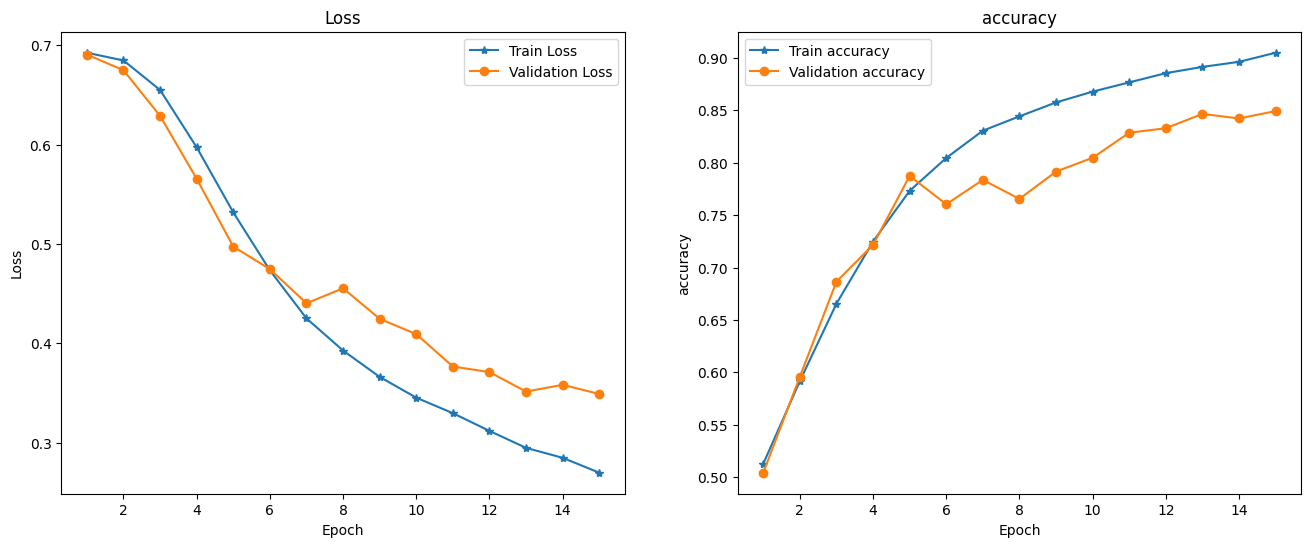

In [34]:
hist = history.history

length = np.arange(len(hist['loss'])) + 1

fig, axes = plt.subplots(1,2, figsize=(16,6))
axes[0].plot(length, hist['loss'], '-*', label='Train Loss')
axes[0].plot(length, hist['val_loss'], '-o', label='Validation Loss')
axes[0].legend(loc='best')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(length, hist['accuracy'], '-*', label='Train accuracy')
axes[1].plot(length, hist['val_accuracy'], '-o', label='Validation accuracy')
axes[1].legend(loc='best')
axes[1].set_title('accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('accuracy')
plt.show()

In [35]:
# pull the learned weights for the embedding layer
embeddings_trained = model.get_layer('embedding').get_weights()[0][1:-1] # exlude the padding (1) on first row and new set (-1) on last row
embeddings_trained.shape

(83961, 10)

### Inspecting Learned Embeddings
- Apply PCA to reduce embeddings to 2D
- Visualize PCA embeddings

In [36]:
pca = PCA(n_components = 2)

embedding_trained_pca = pca.fit_transform(embeddings_trained)

In [37]:
embedding_trained_pca

array([[ 1.9785656e-01, -4.7698244e-04],
       [ 2.2505988e-01, -7.0465994e-01],
       [ 8.5339889e-02, -1.2670649e-02],
       ...,
       [ 7.7188380e-02,  5.6743389e-03],
       [ 5.6023408e-02, -1.8577754e-02],
       [ 8.2311019e-02, -5.6248438e-03]], shape=(83961, 2), dtype=float32)

In [38]:
# pull all words
train_vocab = []
for token in token_counts.keys():
    train_vocab.append(token)

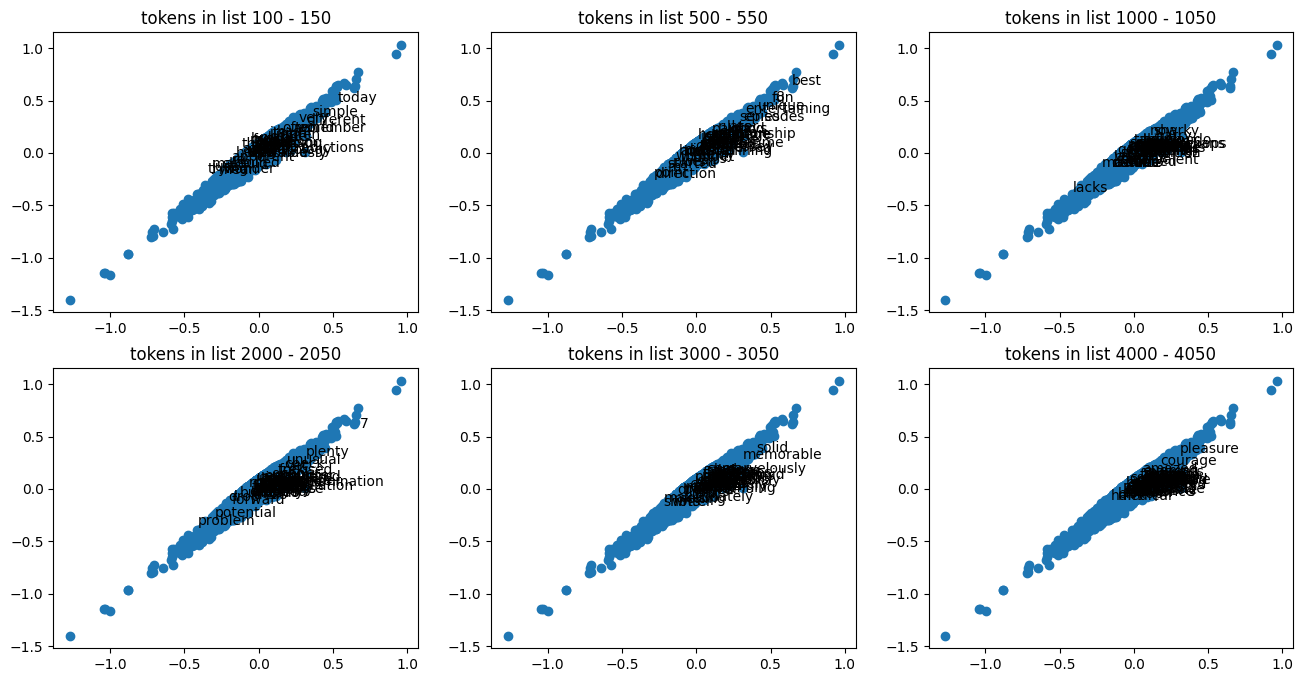

In [39]:
# pull examples works and two embedding columns to review the learned parameters - embeddings
fig, axes = plt.subplots(2,3, figsize=(16,8))
sample_list = [100, 500, 1000, 2000, 3000, 4000, 5000, 6000]
for i, ax in enumerate(axes.flatten()):
    ax.scatter(embeddings_trained[:,1], embeddings_trained[:,2]) # dimension 1 and 2
    ax.set_title(f'tokens in list {sample_list[i]} - {sample_list[i]+50}') # pull 50 samples
    for k in range(sample_list[i], sample_list[i]+50):
        ax.annotate(train_vocab[k], embeddings_trained[k][:2])

#### PCA - Dimension 1

From below charts, we can see pca was able to split the data. Negative words located to the left, positive words located to the right.

10 minimum value words: 
['worst' 'waste' 'bad' 'awful' 'terrible' 'boring' 'poor' 'horrible'
 'worse' 'stupid']

10 maximum value words: 
['favorite' 'brilliant' 'best' 'perfect' '7' 'loved' 'wonderful' 'amazing'
 'excellent' 'great']


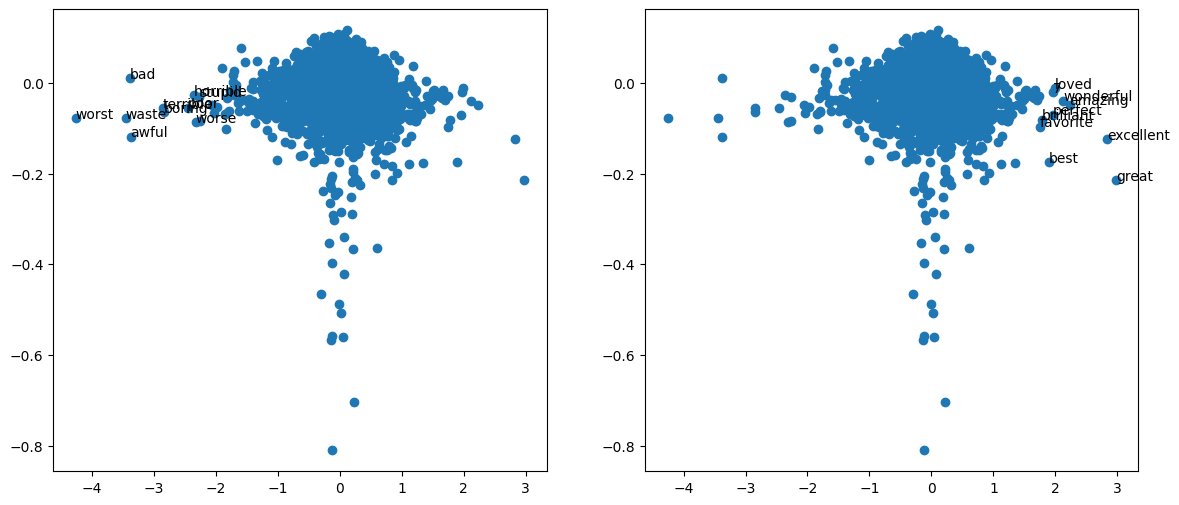

In [40]:
# get top 10 smallest and largest values in dimension 1
top_10_min_indices = np.argsort(embedding_trained_pca[:, 0])[:10]
top_10_max_indices = np.argsort(embedding_trained_pca[:, 0])[-10:]

# pull the words assocaited with the values
top_10_min_words = np.array(train_vocab)[top_10_min_indices]
top_10_max_words = np.array(train_vocab)[top_10_max_indices]

# review the words
print(f'10 minimum value words: \n{top_10_min_words}\n')
print(f'10 maximum value words: \n{top_10_max_words}')

fig, axes = plt.subplots(1,2,figsize=(14,6))
axes[0].scatter(embedding_trained_pca[:,0],embedding_trained_pca[:,1])
for i in range(len(top_10_min_indices)):
    axes[0].annotate(top_10_min_words[i], embedding_trained_pca[top_10_min_indices][i])

axes[1].scatter(embedding_trained_pca[:,0],embedding_trained_pca[:,1])
for i in range(len(top_10_min_indices)):
    axes[1].annotate(top_10_max_words[i], embedding_trained_pca[top_10_max_indices][i])

#### PCA - Dimension 2

10 minimum value words: 
['the' 'and' 'of' 'in' 'a' 'is' 'his' 'to' 'as' 's']

10 maximum value words: 
['gonzongas' 'snakes' 'peaked' 'dove' 'blondes' 'slasher' 'koirala'
 'cherkassov' 'mccrae' 'snowman']


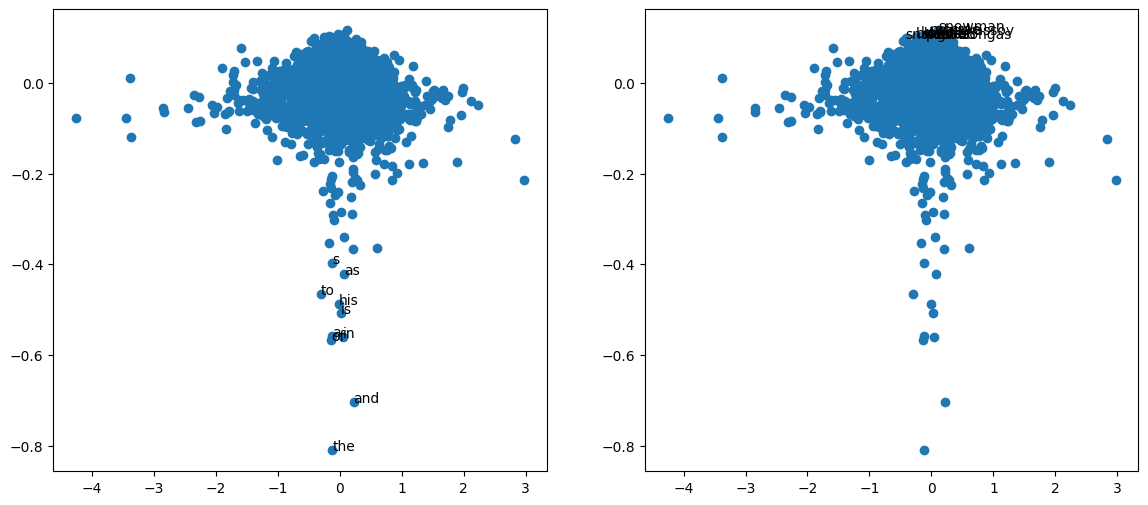

In [41]:
# get top 10 smallest and largest values in dimension 1
top_10_min_indices = np.argsort(embedding_trained_pca[:, 1])[:10]
top_10_max_indices = np.argsort(embedding_trained_pca[:, 1])[-10:]

# pull the words assocaited with the values
top_10_min_words = np.array(train_vocab)[top_10_min_indices]
top_10_max_words = np.array(train_vocab)[top_10_max_indices]

# review the words
print(f'10 minimum value words: \n{top_10_min_words}\n')
print(f'10 maximum value words: \n{top_10_max_words}')

fig, axes = plt.subplots(1,2,figsize=(14,6))
axes[0].scatter(embedding_trained_pca[:,0],embedding_trained_pca[:,1])
for i in range(len(top_10_min_indices)):
    axes[0].annotate(top_10_min_words[i], embedding_trained_pca[top_10_min_indices][i])

axes[1].scatter(embedding_trained_pca[:,0],embedding_trained_pca[:,1])
for i in range(len(top_10_min_indices)):
    axes[1].annotate(top_10_max_words[i], embedding_trained_pca[top_10_max_indices][i])